# Normalization



# **1. What is Normalization in Machine Learning?**

**Normalization** is a **feature scaling technique** used to **rescale numeric features into a fixed range**, usually:

* **[0, 1]**
  or sometimes
* **[-1, 1]**

The most common method is **Min–Max Normalization**.

---

## **Normalization Formula (Min–Max Scaling)**

X(Norm)= X-Xmin / Xmax-Xmin


Where:

* (x) = original value
* (x_{min}) = minimum value of the feature
* (x_{max}) = maximum value of the feature

---


Now all values will lie **between 0 and 1**.

---

# **2. Why Do We Use Normalization? (Detailed Reasons)**

---

## **1️⃣ To bring all features to the same scale**

In real datasets, features have **different units and ranges**:

| Feature    | Range            |
| ---------- | ---------------- |
| Age        | 18 – 65          |
| Salary     | 20,000 – 200,000 |
| Experience | 0 – 40           |

Without normalization:

* Salary dominates model learning
* Age & experience become less important

Normalization ensures **fair contribution of all features**.

---

## **2️⃣ Improves performance of distance-based algorithms**

Algorithms like:

* **K-Nearest Neighbors (KNN)**
* **K-Means Clustering**
* **Support Vector Machine (SVM)**

use **distance calculations**.

Distance formula example:
[
\sqrt{(x_1-x_2)^2 + (y_1-y_2)^2}
]

If data is not normalized:

* Large values dominate distance
* Nearest neighbors become incorrect

Normalization fixes this problem.

---

## **3️⃣ Speeds up training in gradient-based algorithms**

Algorithms such as:

* **Linear Regression**
* **Logistic Regression**
* **Neural Networks**

use **Gradient Descent**.

Without scaling:

* Loss surface becomes skewed
* Training is **slow and unstable**

Normalization makes learning **faster and smoother**.

---

## **4️⃣ Required for image and deep learning models**

Pixel values in images:

* Range: **0–255**

Normalization:

* Converts them to **0–1**
* Improves training stability
* Prevents exploding gradients

That’s why **normalization is mandatory in Deep Learning**.

---

## **5️⃣ Helps models converge to better solutions**

* Features become comparable
* Optimization becomes efficient
* Model accuracy improves

---

# **3. Why Scaling Is Important in Machine Learning?**

👉 **Normalization is a type of scaling**.

### **Scaling is important because:**

---

### **✔ Prevents feature dominance**

Large-scale features do not overpower smaller ones.

---

### **✔ Improves model accuracy**

Models learn meaningful patterns instead of biased ones.

---

### **✔ Makes optimization easier**

Gradient descent converges faster.

---

### **✔ Essential for regularization**

Lasso & Ridge penalize features fairly **only when data is scaled**.

---

### **✔ Ensures numerical stability**

Prevents overflow/underflow in calculations.

---

# **4. Normalization vs Standardization (Quick Comparison)**

| Aspect                | Normalization   | Standardization      |
| --------------------- | --------------- | -------------------- |
| Range                 | Fixed (0–1)     | Mean 0, Std 1        |
| Formula               | Min–Max         | Z-Score              |
| Sensitive to outliers | Yes             | Less                 |
| Best for              | Images, NN, KNN | Regression, PCA, SVM |

---

# **5. When to Use Normalization?**

✅ Use Normalization when:

* Data has **fixed min & max**
* Working with **images**
* Using **KNN, K-Means, Neural Networks**

❌ Not required for:

* Decision Trees
* Random Forest
* XGBoost
  (these are scale-independent)

---

# **6. Simple Real-Life Analogy**

Imagine:

* Height in **cm**
* Weight in **kg**
* Salary in **lakhs**

If you don’t scale:

* Salary controls all decisions

Normalization is like **converting everything into percentages** so comparisons are fair.

---

## **Final Summary**

* Normalization rescales data to a fixed range (0–1)**
* Prevents feature dominance**
* Improves accuracy, speed, and stability**
* Essential for distance & gradient-based models**




In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive


In [79]:
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [80]:
df=pd.read_csv("/content/drive/MyDrive/WineQT.csv")

In [81]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [82]:
df=df[["fixed acidity","residual sugar","free sulfur dioxide"]]
df

,fixed acidity,residual sugar,free sulfur dioxide
0,7.4,1.9,11.0
1,7.8,2.6,25.0
2,7.8,2.3,15.0
3,11.2,1.9,17.0
4,7.4,1.9,11.0
...,...,...,...
1138,6.3,2.3,29.0
1139,6.8,1.9,28.0
1140,6.2,2.0,32.0
1141,5.9,2.2,39.0


<Axes: xlabel='fixed acidity', ylabel='Density'>

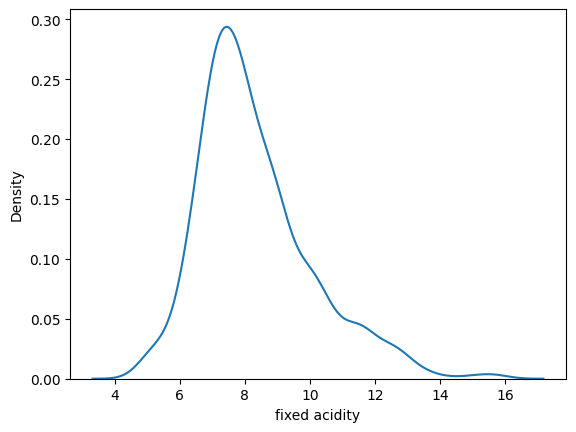

In [83]:
sns.kdeplot(df['fixed acidity'])

<Axes: xlabel='residual sugar', ylabel='Density'>

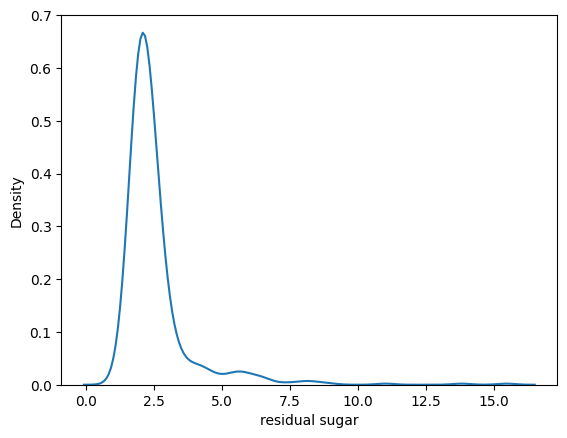

In [84]:
sns.kdeplot(df['residual sugar'])

<Axes: xlabel='free sulfur dioxide', ylabel='Density'>

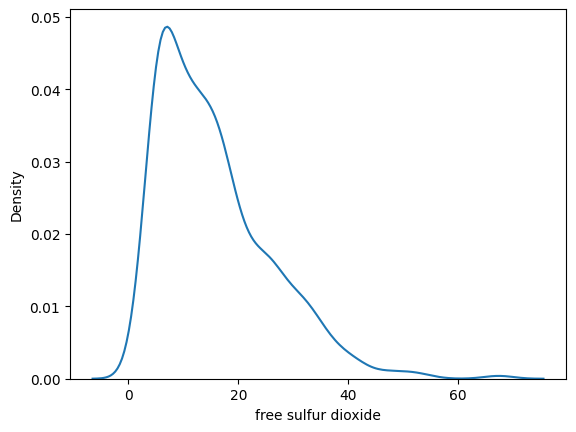

In [85]:
sns.kdeplot(df['free sulfur dioxide'])

In [86]:
x=df.drop("free sulfur dioxide",axis=1)
y=df['free sulfur dioxide']

In [87]:
x

,fixed acidity,residual sugar
0,7.4,1.9
1,7.8,2.6
2,7.8,2.3
3,11.2,1.9
4,7.4,1.9
...,...,...
1138,6.3,2.3
1139,6.8,1.9
1140,6.2,2.0
1141,5.9,2.2


In [88]:
y

,free sulfur dioxide
0,11.0
1,25.0
2,15.0
3,17.0
4,11.0
...,...
1138,29.0
1139,28.0
1140,32.0
1141,39.0


In [89]:
from sklearn.model_selection import train_test_split

In [90]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

In [91]:
x_train.shape,x_test.shape

((800, 2), (343, 2))

In [92]:
from sklearn.preprocessing import MinMaxScaler

In [93]:
scalar=MinMaxScaler()

# fit the scaler to the train set, it will learn the parameters
scalar.fit(x_train)

# transform train and test sets

x_train_scaled=scalar.transform(x_train)
x_test_scaled=scalar.transform(x_test)


In [94]:
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [95]:
x_train.describe()

,fixed acidity,residual sugar
count,800.000000,800.000000
mean,8.252125,2.581750
std,1.719125,1.446981
min,4.900000,0.900000
25%,7.100000,1.900000
50%,7.900000,2.200000
75%,9.100000,2.600000
max,15.900000,15.500000


In [96]:
x_train_scaled.describe()

,fixed acidity,residual sugar
count,800.000000,800.000000
mean,0.304739,0.115188
std,0.156284,0.099108
min,0.000000,0.000000
25%,0.200000,0.068493
50%,0.272727,0.089041
75%,0.381818,0.116438
max,1.000000,1.000000


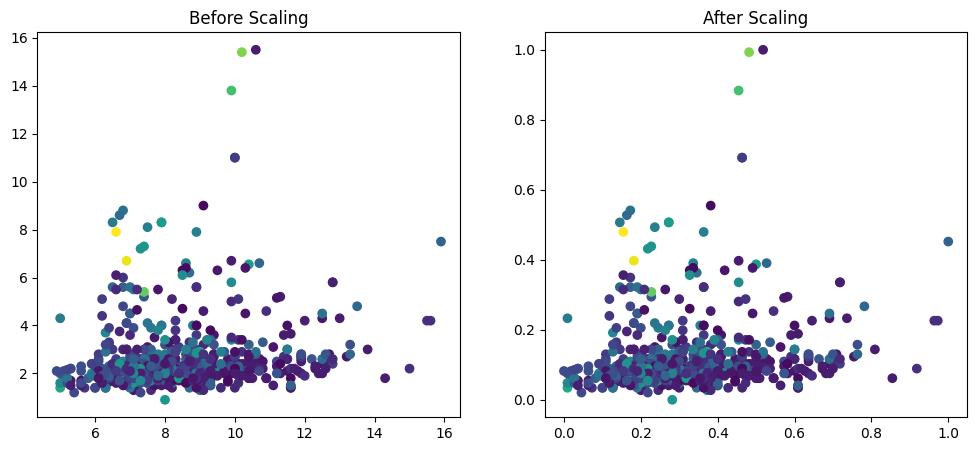

In [97]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
ax1.scatter(x_train['fixed acidity'], x_train['residual sugar'],c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scaled['fixed acidity'], x_train_scaled['residual sugar'],c=y_train)
ax2.set_title("After Scaling")
plt.show()


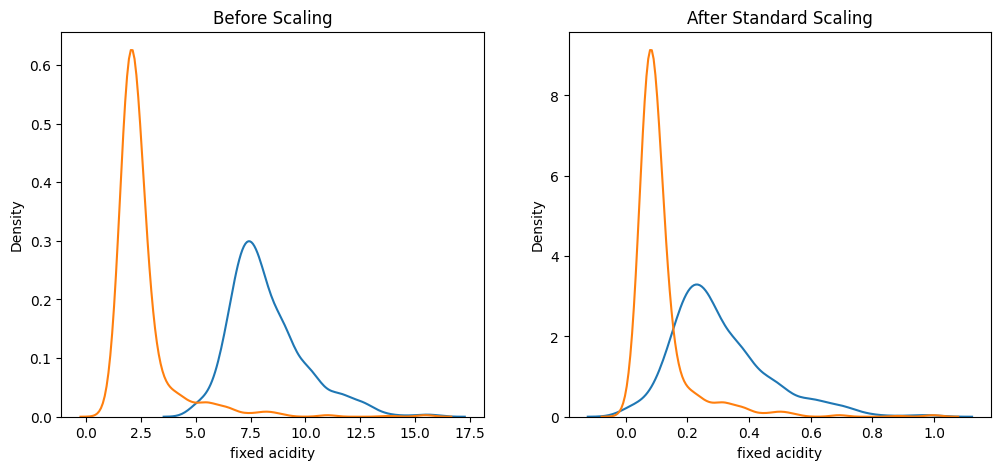

In [98]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))


# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(x_train['fixed acidity'], ax=ax1)
sns.kdeplot(x_train['residual sugar'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(x_train_scaled['fixed acidity'], ax=ax2)
sns.kdeplot(x_train_scaled['residual sugar'], ax=ax2)
plt.show()

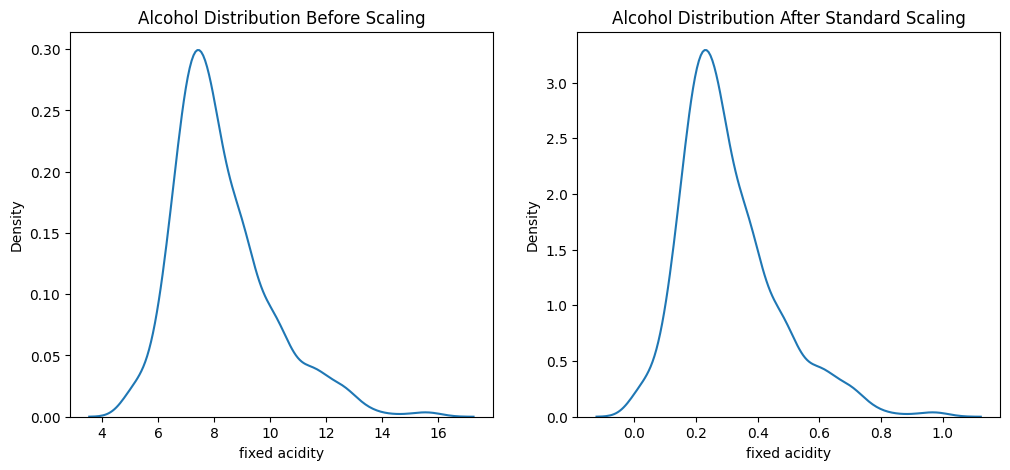

In [99]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(x_train['fixed acidity'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(x_train_scaled['fixed acidity'], ax=ax2)
plt.show()

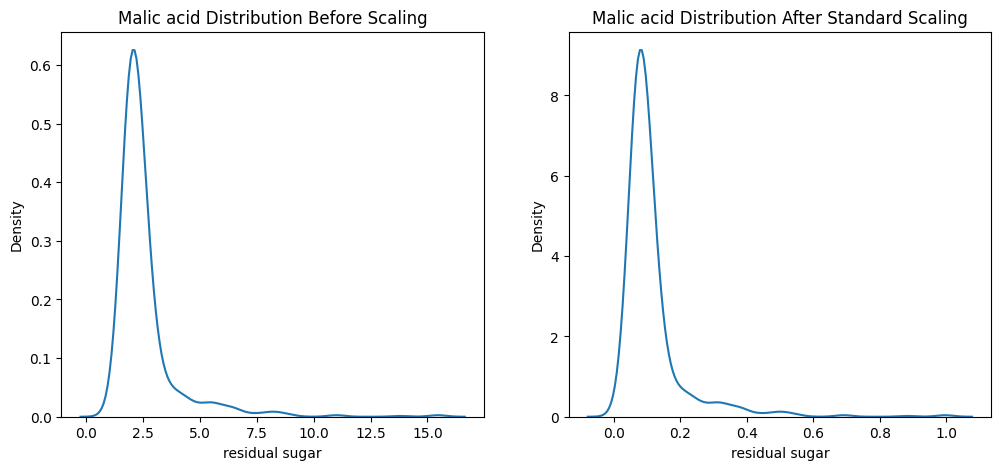

In [100]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))


# before scaling
ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(x_train['residual sugar'], ax=ax1)
# after scaling
ax2.set_title('Malic acid Distribution After Standard Scaling')
sns.kdeplot(x_train_scaled['residual sugar'], ax=ax2)
plt.show()

